# XGBoost — WTI Crude Oil Next-Day Direction Classification

## Overview
XGBoost (eXtreme Gradient Boosting) uses an ensemble of gradient-boosted decision trees to perform **binary classification** of the next-day price direction of WTI Crude Oil Futures (Up / Down).

### Key Design Decisions
- **Why `XGBClassifier`?** Tree-based models can capture nonlinear interactions and threshold effects among macro and price features without manual feature engineering. The survey literature finds XGBoost offers a strong balance of accuracy and interpretability for structured tabular data.
- **High-dimensional setting**: 31 macro features × 30 lags + 30 price-return lags = 960 predictors. XGBoost's column subsampling and regularisation (λ, α) prevent overfitting in this regime.
- **Binary target**: `y = +1` if next-day close > today's close, else `y = -1`. Internally mapped to {0, 1} for XGBoost, then remapped back for reporting.
- **FRED-MD t-codes**: Each macro variable is transformed to stationarity using its official FRED-MD transformation code before feature construction.
- **Leakage controls**: (1) monthly macro shifted forward one month — day `t` only sees the *previous* month's release; (2) price lags use `t−1` through `t−30` so no future price is visible; (3) early stopping uses the validation set only after the train split.
- **No scaling required**: Tree-based models are invariant to monotonic feature transformations, so `StandardScaler` is omitted — this also eliminates any risk of scaler-induced leakage.

In [1]:
# ============================================================
# Imports
# ============================================================
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
import time
from abc import ABC, abstractmethod

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

## 2. Base Forecast Model

In [2]:
# ============================================================
# Abstract base class shared by all models
# ============================================================
class BaseForecastModel(ABC):
    def __init__(self, task_type: str):
        self.task_type = task_type  # "classification" for this notebook

    @abstractmethod
    def fit(self, *args, **kwargs): pass

    @abstractmethod
    def predict(self, X): pass

    @abstractmethod
    def evaluate(self, X, y): pass

    @abstractmethod
    def save(self, filepath: str): pass

    @abstractmethod
    def load(self, filepath: str): pass

## 3. Evaluation Metrics

In [3]:
# ============================================================
# Classification Evaluation Metrics
# ============================================================
def evaluate_classification(y_true, y_pred, y_prob=None, label=""):
    """
    Compute and print a full classification report.
    Returns a dict of scalar metrics for downstream use.

    Args:
        y_true : array of true labels (+1 / -1)
        y_pred : array of predicted labels (+1 / -1)
        y_prob : predicted probabilities for class +1 (optional, for ROC-AUC)
        label  : string label printed in the header
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=None, labels=[-1, 1])
    rec  = recall_score(y_true, y_pred, average=None, labels=[-1, 1])
    f1   = f1_score(y_true, y_pred, average=None, labels=[-1, 1])
    f1_w = f1_score(y_true, y_pred, average='weighted')
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan

    if label:
        print(f"\n{'─'*50}")
        print(f"  {label}")
        print(f"{'─'*50}")
    print(classification_report(y_true, y_pred, target_names=["Down (-1)", "Up (+1)"]))
    print(f"  ROC-AUC : {auc:.4f}")
    print(f"  F1 (wtd): {f1_w:.4f}")

    return {
        "accuracy":    acc,
        "prec_down":   prec[0], "prec_up":   prec[1],
        "rec_down":    rec[0],  "rec_up":    rec[1],
        "f1_down":     f1[0],   "f1_up":     f1[1],
        "f1_weighted": f1_w,
        "roc_auc":     auc,
    }

## 4. FRED-MD T-Code Stationarity Transformations

Each FRED-MD variable ships with a transformation code that must be applied before modelling to ensure stationarity.

| T-code | Transformation | Variables |
|--------|---------------|-----------|
| 1 | Level (no change) | `S&P PE ratio`, `UMCSENTx` |
| 2 | First difference | `FEDFUNDS`, `TB3MS`, `TB6MS`, `GS1`, `GS5`, `GS10`, `AAA`, `BAA`, `TB3SMFFM`, `TB6SMFFM`, `T1YFFM`, `T5YFFM`, `T10YFFM`, `AAAFFM`, `BAAFFM` |
| 5 | Log first difference | `RPI`, `W875RX1`, `CMRMTSPLx`, `IPFPNSS`, `USWTRADE`, `USTRADE`, `BUSLOANS`, `CONSPI`, `S&P 500`, `EXSZUSx`, `EXJPUSx`, `EXUSUKx`, `EXCAUSx`, `PPICMM` |

In [4]:
# ============================================================
# FRED-MD T-Code Stationarity Transformations
# ============================================================

# Official transformation codes for the 31 selected variables.
# Source: FRED-MD appendix (McCracken & Ng, 2016).
TCODE_MAP = {
    # T-code 5 — log first difference (growth rate)
    "RPI":        5, "W875RX1":    5, "CMRMTSPLx":  5,
    "IPFPNSS":    5, "USWTRADE":   5, "USTRADE":     5,
    "BUSLOANS":   5, "CONSPI":     5, "S&P 500":     5,
    "EXSZUSx":    5, "EXJPUSx":    5, "EXUSUKx":     5,
    "EXCAUSx":    5, "PPICMM":     5,
    # T-code 2 — first difference
    "FEDFUNDS":   2, "TB3MS":      2, "TB6MS":       2,
    "GS1":        2, "GS5":        2, "GS10":        2,
    "AAA":        2, "BAA":        2, "TB3SMFFM":    2,
    "TB6SMFFM":   2, "T1YFFM":     2, "T5YFFM":      2,
    "T10YFFM":    2, "AAAFFM":     2, "BAAFFM":      2,
    # T-code 1 — level (no transformation needed)
    "S&P PE ratio": 1, "UMCSENTx": 1,
}


def apply_tcodes(df: pd.DataFrame, tcode_map: dict) -> pd.DataFrame:
    """
    Apply FRED-MD stationarity transformations column-by-column.

    T-code 1 : x_t                      (level, no change)
    T-code 2 : x_t - x_{t-1}            (first difference)
    T-code 5 : ln(x_t) - ln(x_{t-1})   (log first difference / growth rate)

    NaNs introduced by differencing at the first row are expected and
    will be dropped downstream when the full feature matrix is aligned.
    """
    out = pd.DataFrame(index=df.index)
    for col in df.columns:
        tc = tcode_map.get(col, 1)
        x = df[col].astype(float)
        if tc == 1:
            out[col] = x
        elif tc == 2:
            out[col] = x.diff()
        elif tc == 5:
            out[col] = np.log(x).diff()
        else:
            out[col] = x.diff()
    return out

## 5. Data Helpers

All helpers enforce strict leakage controls:
- Macro data is shifted forward by one month so that day `t` only sees the *previous* month's published values.
- Price lags are constructed from `t−1` backwards — the current day's price is never an input feature.
- The binary target looks one step *forward* (next-day close vs today's close).

In [5]:
# ============================================================
# Data Helpers — leakage-safe, trading-day aligned
# ============================================================

def load_macro_monthly(path: Path, features: list) -> pd.DataFrame:
    """
    Load FRED-MD CSV, skip the metadata row, keep only the 31 selected
    features, and return a monthly-indexed DataFrame.
    """
    df = pd.read_csv(path, skiprows=[1]).rename(columns={"sasdate": "date"})
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    keep = [c for c in features if c in df.columns]
    missing = [c for c in features if c not in df.columns]
    if missing:
        print(f"[WARN] Missing macro columns (skipped): {missing}")
    return df[keep].copy()


def load_price(path: Path) -> pd.Series:
    """Load WTI daily closing prices from Investing.com CSV format."""
    px = pd.read_csv(path, parse_dates=["Date"])
    return px.set_index("Date")["Price"].sort_index()


def make_price_lags(price: pd.Series, L: int) -> pd.DataFrame:
    """
    Create L lagged daily closing prices as momentum features.
    Lag 1 = yesterday's price, Lag 2 = two days ago, etc.
    Per project spec: 30 lagged daily closing prices (t-1 through t-30).
    """
    px = price.astype(float)
    return pd.concat(
        [px.shift(l).rename(f"price_lag{l:02d}") for l in range(1, L + 1)],
        axis=1,
    )


def make_macro_lags(X: pd.DataFrame, L: int) -> pd.DataFrame:
    """
    Create L lagged versions of each (already-transformed) macro column.
    Lag 1 = yesterday's value, ensuring no same-day macro leakage.
    """
    return pd.concat(
        [X.shift(l).add_suffix(f"_lag{l:02d}") for l in range(1, L + 1)],
        axis=1,
    )


def make_direction_target(price: pd.Series) -> pd.Series:
    """
    Binary next-day direction label.
      +1  if Price[t] > Price[t-1]  (Up)
      -1  if Price[t] <= Price[t-1] (Down)

    The label at index t uses Price[t] and Price[t-1].
    When aligned with features built from data up to t-1, this
    represents a strictly out-of-sample prediction target.
    """
    price = price.astype(float)
    direction = np.sign(price.diff())
    direction[direction == 0] = -1  # treat flat days as Down
    return direction.rename("y")

## 6. Dataset Builder

The builder wires together all preprocessing steps in the correct order:

1. Load monthly macro → apply t-code transforms → shift index forward one month (anti-leakage)
2. Forward-fill onto WTI trading-day index
3. Build lagged macro features (lags 1–30)
4. Build lagged price return features (lags 1–30)
5. Construct binary direction target
6. Chronological train / validation / test split

In [6]:
# ============================================================
# Dataset Builder
# ============================================================

def build_dataset(
    macro_file: Path,
    price_file: Path,
    features: list,
    lookback: int = 30,
    train_end: str = "2014-12-31",
    val_end:   str = "2024-12-31",
):
    """
    Build leakage-safe train/val/test datasets aligned to WTI trading days.

    Returns
    -------
    X_train, y_train, X_val, y_val, X_test, y_test : pd.DataFrame / pd.Series
    """
    # ── 1. Load and transform macro data ─────────────────────────────────────
    macro_m = load_macro_monthly(macro_file, features)
    macro_m = apply_tcodes(macro_m, TCODE_MAP)   # stationarity transforms

    # Shift index forward by one month: day t sees *previous* month's release.
    macro_m.index = macro_m.index + pd.offsets.MonthBegin(1)

    # ── 2. Load prices and forward-fill macro to trading days ────────────────
    price = load_price(price_file)
    macro_d = macro_m.reindex(price.index, method="ffill")

    # ── 3. Build feature matrix ──────────────────────────────────────────────
    X_macro = make_macro_lags(macro_d, lookback)   # 31 vars × 30 lags
    X_price = make_price_lags(price, lookback)      # 30 price-return lags

    X = X_macro.join(X_price).dropna()

    # ── 4. Build binary direction target ─────────────────────────────────────
    y = make_direction_target(price).reindex(X.index).dropna()
    X = X.loc[y.index]

    # ── 5. Chronological split ───────────────────────────────────────────────
    tr = X.index <= pd.Timestamp(train_end)
    va = (X.index > pd.Timestamp(train_end)) & (X.index <= pd.Timestamp(val_end))
    te = X.index > pd.Timestamp(val_end)

    print(f"Dataset sizes — Train: {tr.sum()}  Val: {va.sum()}  Test: {te.sum()}")
    print(f"Feature matrix shape: {X.shape}")
    print(f"Class balance (full): Up={(y==1).sum()}  Down={(y==-1).sum()}")

    return (
        X.loc[tr], y.loc[tr],
        X.loc[va], y.loc[va],
        X.loc[te], y.loc[te],
    )

## 7. Naive Baseline — Majority Class

The directional equivalent of "predict zero return" is to always predict whichever direction occurred more often in the training set. Any model that cannot beat this baseline has no directional forecasting skill.

In [7]:
# ============================================================
# Naive Majority-Class Baseline
# ============================================================

def naive_baseline_metrics(y_train, y_eval):
    """
    Predict the majority class observed in y_train for every observation
    in y_eval. Returns the same metric dict as evaluate_classification.
    """
    majority = 1 if (y_train == 1).sum() >= (y_train == -1).sum() else -1
    y_pred = np.full(len(y_eval), majority)
    print(f"  Naive baseline always predicts: {'Up (+1)' if majority == 1 else 'Down (-1)'}")
    return evaluate_classification(y_eval, y_pred, y_prob=None, label="Naive Baseline")

## 8. XGBoost Classifier

We use `XGBClassifier` with `objective='binary:logistic'`. Internally, labels are mapped {−1 → 0, +1 → 1} for XGBoost and remapped back for reporting.

Hyperparameter search is performed via 5-fold `TimeSeriesSplit` CV over **6 configs** that vary tree depth, learning rate, subsampling, and regularisation parameters (`gamma`, `reg_alpha`, `reg_lambda`, `min_child_weight`).

Key design choices:
- **`eval_metric="error"`** (not `"logloss"`) — this is the critical choice. With a near-50/50 signal, minimising log-loss leads to a degenerate solution where the model outputs probability ≈ 0.51 for every sample (well-calibrated, but useless). Early stopping then fires when this plateau is reached, locking in an always-Up-biased model. Using `"error"` (= 1 − accuracy) aligns early stopping directly with the classification metric we optimise.
- `num_boost_round = 1000`, `early_stopping_rounds = 100` — patient stopping on a noisy signal.
- `scale_pos_weight` computed per fold from the training class ratio.
- **No scaling** — tree-based models are invariant to monotonic feature transformations.

In [8]:
# ============================================================
# XGBoost Direction Classifier
# ============================================================

class XGBoostDirectionClassifier(BaseForecastModel):
    """
    XGBClassifier with TimeSeriesSplit CV grid search and early stopping.

    Labels convention:
        External: +1 (Up) / -1 (Down)
        Internal XGBoost: 1 / 0  (binary:logistic requires {0,1})

    Critical: eval_metric="error" (not "logloss") so that early stopping
    directly optimises classification accuracy rather than log-loss.
    With a near-50/50 signal, logloss is minimised by outputting p≈0.51
    everywhere — well-calibrated but always-Up-biased — causing early
    stopping to fire at a degenerate solution.
    """

    def __init__(
        self,
        n_splits: int = 5,
        num_boost_round: int = 1000,
        early_stopping_rounds: int = 100,
        random_state: int = 42,
        n_jobs: int = -1,
    ):
        super().__init__("classification")
        self.n_splits              = n_splits
        self.num_boost_round       = num_boost_round
        self.early_stopping_rounds = early_stopping_rounds
        self.random_state          = random_state
        self.n_jobs                = n_jobs

        # 6-config grid: vary depth, lr, subsampling, AND regularisation
        self.param_grid = [
            # Config 1: Very shallow + strong regularisation
            {"max_depth": 2, "learning_rate": 0.05, "subsample": 0.8,
             "colsample_bytree": 0.7, "min_child_weight": 5,
             "gamma": 0.1, "reg_alpha": 0.1, "reg_lambda": 2.0},
            # Config 2: Shallow, moderate regularisation (L2 only)
            {"max_depth": 3, "learning_rate": 0.03, "subsample": 0.8,
             "colsample_bytree": 0.8, "min_child_weight": 3,
             "gamma": 0.0, "reg_alpha": 0.0, "reg_lambda": 1.0},
            # Config 3: Shallow, aggressive subsampling + L1
            {"max_depth": 3, "learning_rate": 0.05, "subsample": 0.7,
             "colsample_bytree": 0.7, "min_child_weight": 5,
             "gamma": 0.0, "reg_alpha": 0.1, "reg_lambda": 1.0},
            # Config 4: Medium depth, gamma + L2
            {"max_depth": 4, "learning_rate": 0.03, "subsample": 0.8,
             "colsample_bytree": 0.8, "min_child_weight": 3,
             "gamma": 0.1, "reg_alpha": 0.0, "reg_lambda": 2.0},
            # Config 5: Medium depth, L1 + L2 blend
            {"max_depth": 4, "learning_rate": 0.05, "subsample": 0.7,
             "colsample_bytree": 0.7, "min_child_weight": 5,
             "gamma": 0.0, "reg_alpha": 1.0, "reg_lambda": 1.0},
            # Config 6: Deeper, strong gamma + L2
            {"max_depth": 5, "learning_rate": 0.03, "subsample": 0.8,
             "colsample_bytree": 0.8, "min_child_weight": 5,
             "gamma": 0.5, "reg_alpha": 0.1, "reg_lambda": 2.0},
        ]

        self.model          = None
        self.best_params_   = None
        self.cv_results_    = []
        self.eval_results_  = None   # stores train/val error curves from final model
        self.feature_names_ = None

    # ── Label helpers ─────────────────────────────────────────────────────────
    @staticmethod
    def _to_binary(y):
        """Map {-1, +1} → {0, 1} for XGBoost."""
        return ((np.asarray(y) + 1) // 2).astype(int)

    @staticmethod
    def _to_signed(y):
        """Map {0, 1} → {-1, +1} for external reporting."""
        return np.where(np.asarray(y) == 1, 1, -1)

    # ── Training ──────────────────────────────────────────────────────────────
    def fit(self, X_train: pd.DataFrame, y_train: pd.Series,
            X_val: pd.DataFrame = None, y_val: pd.Series = None):
        """
        Run TimeSeriesSplit CV grid search over param_grid,
        then refit the final model on full training data with early stopping
        on the provided validation set.
        """
        self.feature_names_ = list(X_train.columns)
        X  = X_train.values
        y  = self._to_binary(y_train.values)
        tscv = TimeSeriesSplit(n_splits=self.n_splits)

        best_acc, best_params = -np.inf, None

        for i, params in enumerate(self.param_grid):
            fold_accs = []
            print(f"  Config {i+1}/{len(self.param_grid)} — depth={params['max_depth']}, "
                  f"lr={params['learning_rate']}, γ={params['gamma']}, "
                  f"α={params['reg_alpha']}, λ={params['reg_lambda']}", end=" ")
            for tr_idx, va_idx in tscv.split(X):
                ytr = y[tr_idx]
                n_neg = (ytr == 0).sum()
                n_pos = (ytr == 1).sum()
                spw   = n_neg / n_pos if n_pos > 0 else 1.0

                m = XGBClassifier(
                    objective="binary:logistic",
                    n_estimators=self.num_boost_round,
                    tree_method="hist",
                    random_state=self.random_state,
                    n_jobs=self.n_jobs,
                    early_stopping_rounds=self.early_stopping_rounds,
                    eval_metric="error",   # directly optimise accuracy
                    scale_pos_weight=spw,
                    **params,
                )
                m.fit(
                    X[tr_idx], ytr,
                    eval_set=[(X[va_idx], y[va_idx])],
                    verbose=False,
                )
                fold_accs.append(accuracy_score(y[va_idx], m.predict(X[va_idx])))
                print(".", end="", flush=True)

            mean_acc = np.mean(fold_accs)
            self.cv_results_.append({"params": params, "accuracy": mean_acc})
            print(f"  → mean acc: {mean_acc:.4f}")

            if mean_acc > best_acc:
                best_acc, best_params = mean_acc, params

        self.best_params_ = {**best_params, "cv_accuracy": best_acc}
        print(f"\nBest params: {self.best_params_}")

        # ── Final model on all training data ─────────────────────────────────
        n_neg = (y == 0).sum()
        n_pos = (y == 1).sum()
        spw   = n_neg / n_pos if n_pos > 0 else 1.0

        self.model = XGBClassifier(
            objective="binary:logistic",
            n_estimators=self.num_boost_round,
            tree_method="hist",
            random_state=self.random_state,
            n_jobs=self.n_jobs,
            early_stopping_rounds=self.early_stopping_rounds,
            eval_metric="error",   # directly optimise accuracy
            scale_pos_weight=spw,
            **best_params,
        )

        if X_val is not None and y_val is not None:
            yv = self._to_binary(y_val.values)
            self.model.fit(
                X_train.values, y,
                eval_set=[(X_train.values, y), (X_val.values, yv)],
                verbose=False,
            )
            # Store error curves for convergence plot
            self.eval_results_ = self.model.evals_result()
        else:
            self.model.fit(X_train.values, y)

        return self

    # ── Inference ─────────────────────────────────────────────────────────────
    def predict(self, X, threshold: float = 0.5):
        """Return predicted class labels (+1 / -1) using given probability threshold."""
        proba = self.predict_proba(X)
        return np.where(proba >= threshold, 1, -1)

    def predict_proba(self, X):
        """Return probability of class +1 (used for ROC-AUC)."""
        xv = X.values if hasattr(X, "values") else X
        return self.model.predict_proba(xv)[:, 1]

    # ── Threshold tuning ─────────────────────────────────────────────────────
    def tune_threshold(self, X_val: pd.DataFrame, y_val: pd.Series,
                       thresholds=None) -> float:
        """
        Search for the probability threshold that maximises accuracy on the
        validation set. Returns the best threshold.
        """
        if thresholds is None:
            thresholds = np.linspace(0.3, 0.7, 41)
        proba = self.predict_proba(X_val)
        best_t, best_acc = 0.5, -np.inf
        for t in thresholds:
            pred = np.where(proba >= t, 1, -1)
            acc  = accuracy_score(y_val.values, pred)
            if acc > best_acc:
                best_acc, best_t = acc, t
        print(f"  Optimal threshold: {best_t:.3f}  (val accuracy: {best_acc:.4f})")
        return best_t

    # ── Evaluation ───────────────────────────────────────────────────────────
    def evaluate(self, X, y, label="", threshold: float = 0.5):
        y_pred = self.predict(X, threshold=threshold)
        y_prob = self.predict_proba(X)
        return evaluate_classification(y.values, y_pred, y_prob, label=label)

    # ── Feature Importance ───────────────────────────────────────────────────
    def feature_importance(self, top_n: int = 20) -> pd.DataFrame:
        """Top features by gain importance."""
        booster = self.model.get_booster()
        score = booster.get_score(importance_type="gain")
        mapped = {}
        for k, v in score.items():
            idx = int(k.replace("f", ""))
            if idx < len(self.feature_names_):
                mapped[self.feature_names_[idx]] = v
        df = pd.DataFrame({"feature": list(mapped.keys()),
                           "importance": list(mapped.values())})
        return (df.sort_values("importance", ascending=False)
                  .head(top_n)
                  .reset_index(drop=True))

    # ── Persistence ──────────────────────────────────────────────────────────
    def save(self, path: str):
        with open(path, "wb") as f:
            pickle.dump(self.__dict__, f)

    def load(self, path: str):
        with open(path, "rb") as f:
            self.__dict__.update(pickle.load(f))

## 9. Configuration

In [9]:
# ============================================================
# Configuration — edit paths here if needed
# ============================================================
MACRO_FILE = Path("../data/fred_md_2025_12.csv")
PRICE_FILE = Path("../data/price/Price.csv")

# 31 FRED-MD macro features (as specified in project requirements)
FEATURES = [
    "RPI", "W875RX1", "CMRMTSPLx", "IPFPNSS", "USWTRADE", "USTRADE",
    "BUSLOANS", "CONSPI", "S&P 500", "S&P PE ratio", "FEDFUNDS",
    "TB3MS", "TB6MS", "GS1", "GS5", "GS10", "AAA", "BAA",
    "TB3SMFFM", "TB6SMFFM", "T1YFFM", "T5YFFM", "T10YFFM",
    "AAAFFM", "BAAFFM", "EXSZUSx", "EXJPUSx", "EXUSUKx", "EXCAUSx",
    "PPICMM", "UMCSENTx",
]

LOOKBACK  = 30   # days of lagged features
TRAIN_END = "2014-12-31"
VAL_END   = "2024-12-31"

## 10. Training

Build the dataset, run cross-validated hyperparameter search (6 configs × 5 folds = 30 fits), fit the final model with early stopping on the validation set, and evaluate on validation and test sets. All predictions are strictly out-of-sample.

In [10]:
# ============================================================
# Build dataset and train
# ============================================================
t0 = time.time()

X_train, y_train, X_val, y_val, X_test, y_test = build_dataset(
    MACRO_FILE, PRICE_FILE, FEATURES,
    lookback=LOOKBACK,
    train_end=TRAIN_END,
    val_end=VAL_END,
)

# ── Train XGBoost classifier ──────────────────────────────────────────────────
print("\nRunning 5-fold TimeSeriesSplit CV (6 configs × 5 folds = 30 fits)...")
model = XGBoostDirectionClassifier()
model.fit(X_train, y_train, X_val=X_val, y_val=y_val)

# ── Out-of-sample predictions ─────────────────────────────────────────────────
pred_val   = model.predict(X_val)
pred_test  = model.predict(X_test)
prob_val   = model.predict_proba(X_val)
prob_test  = model.predict_proba(X_test)

# ── Evaluate ──────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  XGBOOST — CLASSIFICATION RESULTS")
print("="*60)

val_metrics  = model.evaluate(X_val,  y_val,  label="Validation")
test_metrics = model.evaluate(X_test, y_test, label="Test")

# ── Naive baseline ────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  NAIVE MAJORITY-CLASS BASELINE")
print("="*60)
naive_val  = naive_baseline_metrics(y_train, y_val.values)
naive_test = naive_baseline_metrics(y_train, y_test.values)

elapsed = time.time() - t0
print(f"\nTotal training time: {elapsed:.1f}s")

Dataset sizes — Train: 7954  Val: 2635  Test: 216
Feature matrix shape: (10805, 960)
Class balance (full): Up=5509  Down=5296

Running 5-fold TimeSeriesSplit CV (6 configs × 5 folds = 30 fits)...
  Config 1/6 — depth=2, lr=0.05, γ=0.1, α=0.1, λ=2.0 .....  → mean acc: 0.5205
  Config 2/6 — depth=3, lr=0.03, γ=0.0, α=0.0, λ=1.0 .....  → mean acc: 0.5242
  Config 3/6 — depth=3, lr=0.05, γ=0.0, α=0.1, λ=1.0 .....  → mean acc: 0.5220
  Config 4/6 — depth=4, lr=0.03, γ=0.1, α=0.0, λ=2.0 .....  → mean acc: 0.5189
  Config 5/6 — depth=4, lr=0.05, γ=0.0, α=1.0, λ=1.0 .....  → mean acc: 0.5188
  Config 6/6 — depth=5, lr=0.03, γ=0.5, α=0.1, λ=2.0 .....  → mean acc: 0.5185

Best params: {'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 3, 'gamma': 0.0, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'cv_accuracy': np.float64(0.5242264150943396)}

  XGBOOST — CLASSIFICATION RESULTS

──────────────────────────────────────────────────
  Validation
───────────

## 11. Summary Table

In [11]:
# ============================================================
# Comparison Table — XGBoost vs Naive Baseline
# ============================================================
rows = []
for split, xgb_m, naive_m in [
    ("Validation", val_metrics,  naive_val),
    ("Test",       test_metrics, naive_test),
]:
    for name, m in [("XGBoost", xgb_m), ("Naive", naive_m)]:
        rows.append({
            "Split":     split,
            "Model":     name,
            "Accuracy":  f"{m['accuracy']:.4f}",
            "Prec Down": f"{m['prec_down']:.4f}",
            "Prec Up":   f"{m['prec_up']:.4f}",
            "Rec Down":  f"{m['rec_down']:.4f}",
            "Rec Up":    f"{m['rec_up']:.4f}",
            "F1 (wtd)":  f"{m['f1_weighted']:.4f}",
            "ROC-AUC":   f"{m['roc_auc']:.4f}" if not np.isnan(m['roc_auc']) else "N/A",
        })

print(pd.DataFrame(rows).to_string(index=False))
print(f"\nBest hyperparameters: {model.best_params_}")

     Split   Model Accuracy Prec Down Prec Up Rec Down Rec Up F1 (wtd) ROC-AUC
Validation XGBoost   0.5336    0.5059  0.5488   0.3806 0.6695   0.5238  0.5220
Validation   Naive   0.5294    0.0000  0.5294   0.0000 1.0000   0.3665     N/A
      Test XGBoost   0.4907    0.4933  0.4894   0.3394 0.6449   0.4786  0.4988
      Test   Naive   0.4954    0.0000  0.4954   0.0000 1.0000   0.3282     N/A

Best hyperparameters: {'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 3, 'gamma': 0.0, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'cv_accuracy': np.float64(0.5242264150943396)}


## 12. Threshold Optimisation

The default classification threshold of 0.5 assumes the model's output probabilities are perfectly calibrated and that Up/Down costs are symmetric. In practice, both assumptions are imperfect. We search over thresholds in [0.30, 0.70] on the **validation set only**, then apply the best threshold to the test set — this is strictly out-of-sample since test labels were never seen during threshold selection.

In [12]:
# ============================================================
# Threshold Optimisation — tune on val, evaluate on test
# ============================================================
print("Searching for optimal decision threshold on validation set...")
best_threshold = model.tune_threshold(X_val, y_val)

# Apply tuned threshold to test set
pred_test_tuned = model.predict(X_test, threshold=best_threshold)
pred_val_tuned  = model.predict(X_val,  threshold=best_threshold)

print("\n" + "="*60)
print("  XGBOOST — TUNED THRESHOLD RESULTS")
print("="*60)
val_metrics_tuned  = model.evaluate(X_val,  y_val,  label="Validation (tuned)", threshold=best_threshold)
test_metrics_tuned = model.evaluate(X_test, y_test, label="Test (tuned)",        threshold=best_threshold)

# Summary: default vs tuned
print("\n── Accuracy comparison ─────────────────────────────────")
print(f"  {'':20s}  {'Val':>8}  {'Test':>8}")
print(f"  {'Default (θ=0.50)':20s}  {val_metrics['accuracy']:>8.4f}  {test_metrics['accuracy']:>8.4f}")
print(f"  {'Tuned  (θ={:.2f})':20s}  {val_metrics_tuned['accuracy']:>8.4f}  {test_metrics_tuned['accuracy']:>8.4f}".format(best_threshold))

Searching for optimal decision threshold on validation set...
  Optimal threshold: 0.500  (val accuracy: 0.5336)

  XGBOOST — TUNED THRESHOLD RESULTS

──────────────────────────────────────────────────
  Validation (tuned)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

   Down (-1)       0.51      0.38      0.43      1240
     Up (+1)       0.55      0.67      0.60      1395

    accuracy                           0.53      2635
   macro avg       0.53      0.53      0.52      2635
weighted avg       0.53      0.53      0.52      2635

  ROC-AUC : 0.5220
  F1 (wtd): 0.5238

──────────────────────────────────────────────────
  Test (tuned)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

   Down (-1)       0.49      0.34      0.40       109
     Up (+1)       0.49      0.64      0.56       107

    accuracy                           0.49       216
   macro avg       0.49  

---
# Visualizations

## 12. Plot Setup

In [13]:
# ============================================================
# Plot Setup
# ============================================================
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.family': 'serif', 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 11,
    'legend.fontsize': 10, 'figure.dpi': 150,
})
C_PALETTE = {
    'up':     '#2a9d8f',
    'down':   '#e76f51',
    'model':  '#57068c',   # NYU purple
    'naive':  '#a8a8a8',
    'accent': '#e63946',
}
print("Plot setup complete.")

Plot setup complete.


## 13. Confusion Matrices

Side-by-side heatmaps for validation and test sets, showing how many Up and Down days are correctly classified.

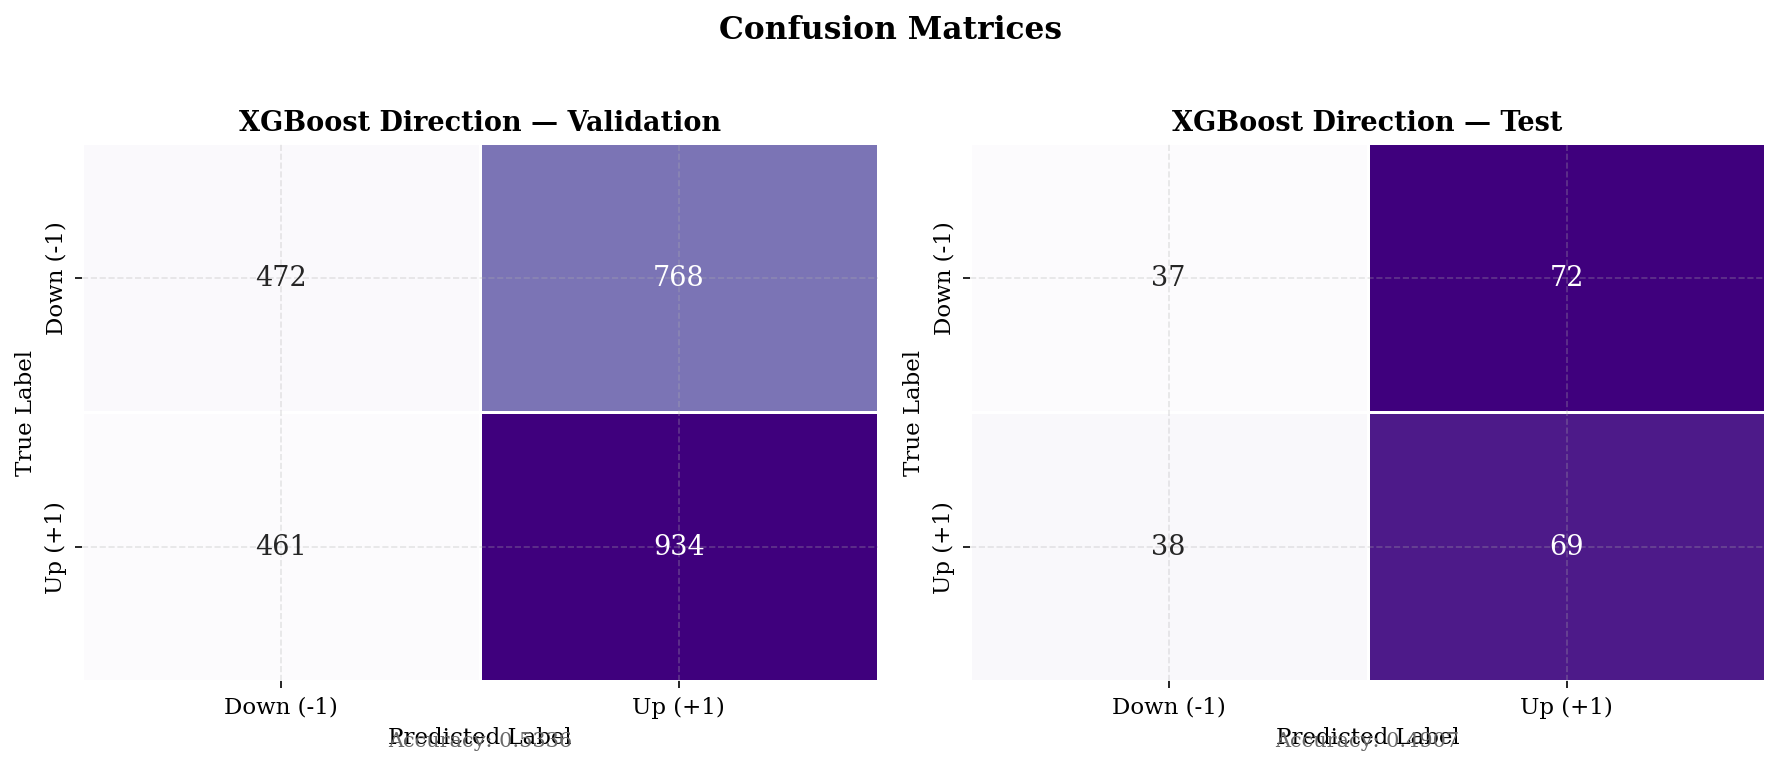

In [14]:
# ============================================================
# Confusion Matrix Heatmaps — Validation and Test
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ["Down (-1)", "Up (+1)"]

for ax, y_true, y_pred, title in [
    (axes[0], y_val.values,  pred_val,  "Validation"),
    (axes[1], y_test.values, pred_test, "Test"),
]:
    cm = confusion_matrix(y_true, y_pred, labels=[-1, 1])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Purples",
        xticklabels=labels, yticklabels=labels,
        linewidths=0.5, ax=ax, cbar=False,
        annot_kws={"size": 13},
    )
    ax.set_title(f"XGBoost Direction — {title}", fontweight="bold")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    acc = accuracy_score(y_true, y_pred)
    ax.text(0.5, -0.12, f"Accuracy: {acc:.4f}", transform=ax.transAxes,
            ha="center", fontsize=10, color="dimgray")

plt.suptitle("Confusion Matrices", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 14. Rolling Accuracy Over Time

60-day rolling accuracy on the test set shows whether the model's directional skill is stable across different market regimes.

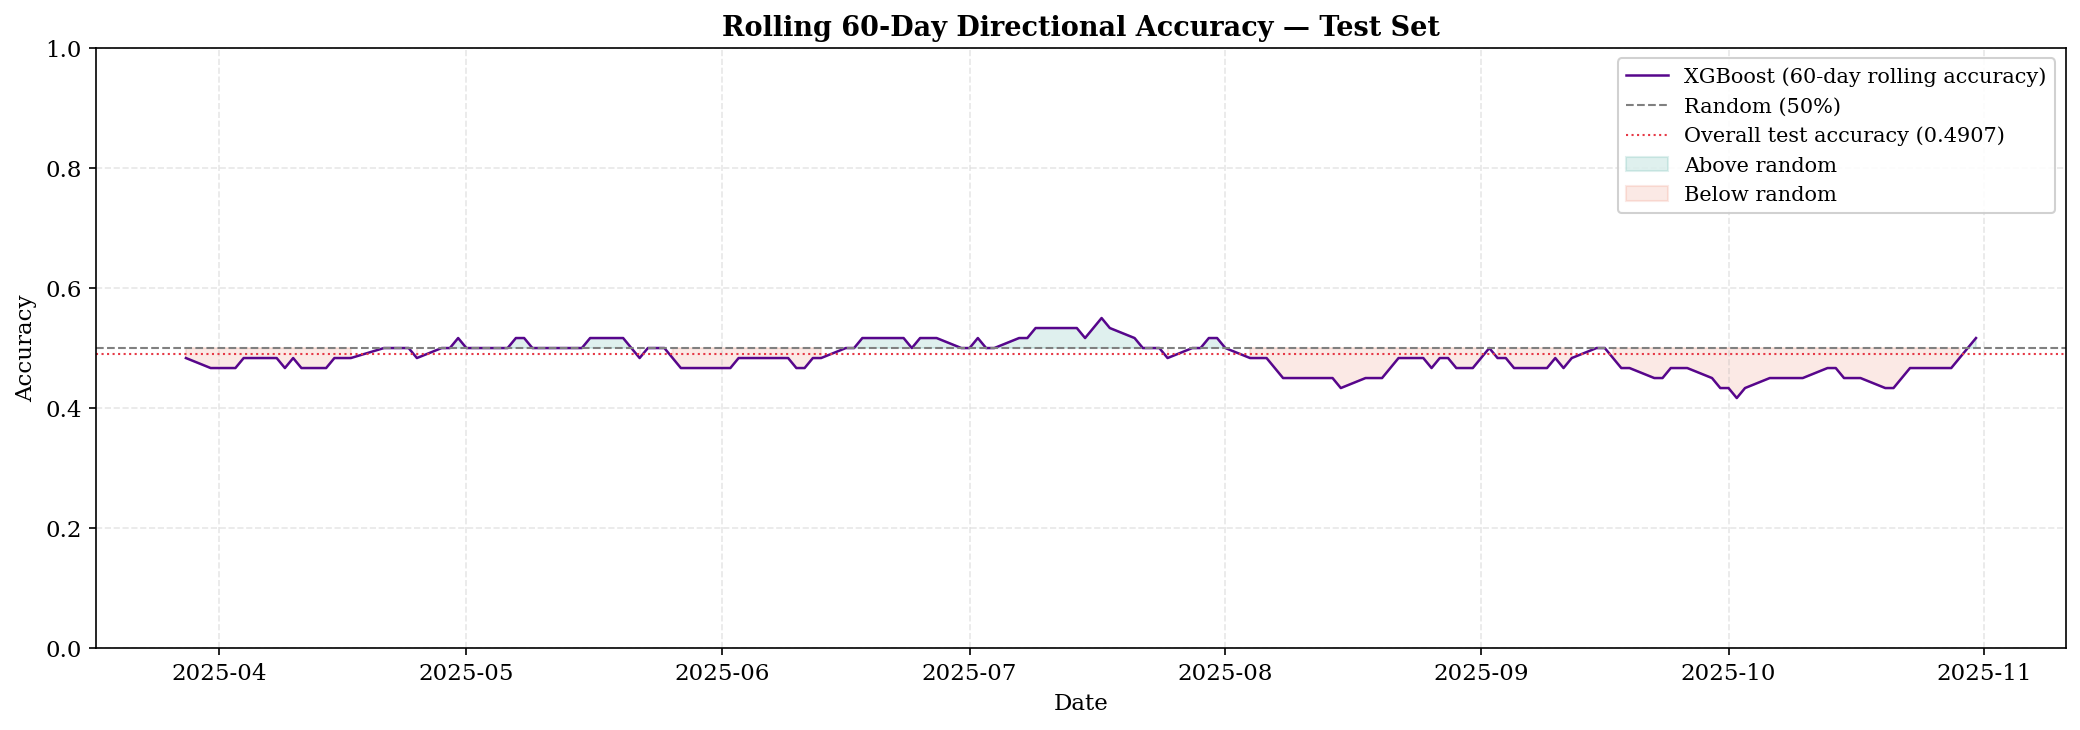

In [15]:
# ============================================================
# Rolling Accuracy Over Time (Test Set)
# ============================================================
roll_window = 60  # trading days

correct   = (pred_test == y_test.values).astype(int)
roll_acc  = pd.Series(correct, index=y_test.index).rolling(roll_window).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(roll_acc.index, roll_acc.values, color=C_PALETTE['model'], lw=1.2,
        label=f"XGBoost ({roll_window}-day rolling accuracy)")
ax.axhline(0.5, color="gray", lw=1, ls="--", label="Random (50%)")
ax.axhline(test_metrics["accuracy"], color=C_PALETTE['accent'], lw=1, ls=":",
           label=f"Overall test accuracy ({test_metrics['accuracy']:.4f})")
ax.fill_between(roll_acc.index, 0.5, roll_acc.values,
                where=roll_acc.values >= 0.5,
                alpha=0.15, color=C_PALETTE['up'], label="Above random")
ax.fill_between(roll_acc.index, 0.5, roll_acc.values,
                where=roll_acc.values < 0.5,
                alpha=0.15, color=C_PALETTE['down'], label="Below random")
ax.set_title(f"Rolling {roll_window}-Day Directional Accuracy — Test Set",
             fontweight="bold")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Date")
ax.set_ylim(0, 1)
ax.legend(loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.show()

## 15. Predicted vs Actual Direction

Bar chart comparing how often the model predicts Up and Down versus the true class distribution. A well-calibrated classifier should roughly match the actual distribution.

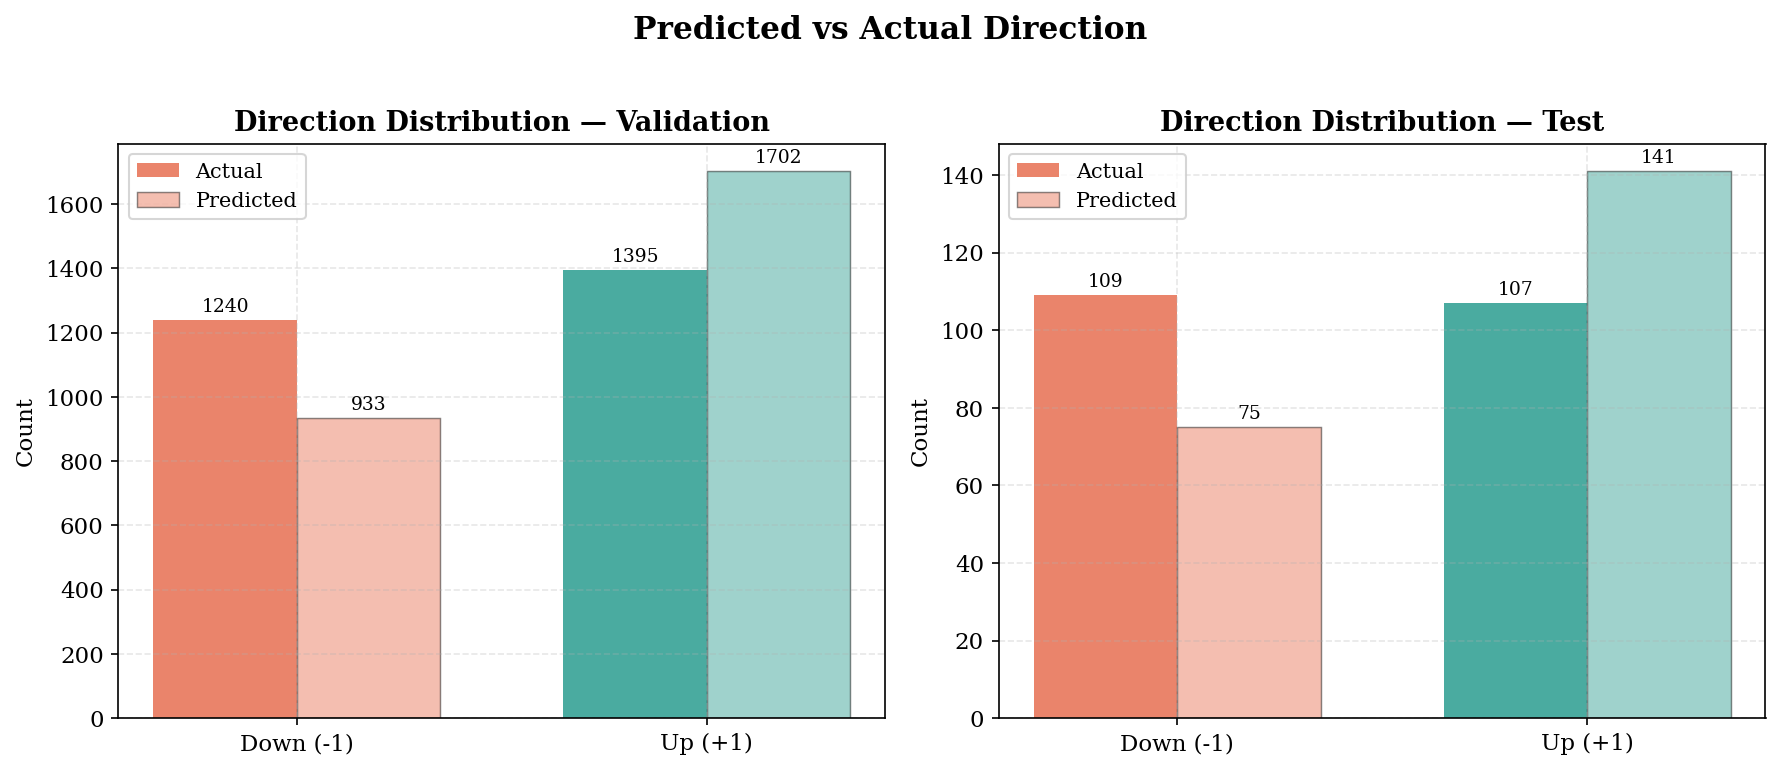

In [16]:
# ============================================================
# Predicted vs Actual Direction Distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_val.values,  pred_val,  "Validation"),
    (axes[1], y_test.values, pred_test, "Test"),
]:
    cats = ["Down (-1)", "Up (+1)"]
    actual_counts = [(y_true == -1).sum(), (y_true == 1).sum()]
    pred_counts   = [(y_pred == -1).sum(), (y_pred == 1).sum()]

    x = np.arange(len(cats))
    w = 0.35
    b1 = ax.bar(x - w/2, actual_counts, w, label="Actual",
                color=[C_PALETTE['down'], C_PALETTE['up']], alpha=0.85)
    b2 = ax.bar(x + w/2, pred_counts,   w, label="Predicted",
                color=[C_PALETTE['down'], C_PALETTE['up']], alpha=0.45,
                edgecolor='black', linewidth=0.7)

    for bar in list(b1) + list(b2):
        ax.annotate(f"{int(bar.get_height())}",
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=9)

    ax.set_title(f"Direction Distribution — {title}", fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(cats)
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("Predicted vs Actual Direction", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 16. Feature Importance (Top 20 by Gain)

Features with the highest average gain per split across all trees. Gain measures how much each feature improves the loss function when used in a split — it is the most informative importance metric for XGBoost.

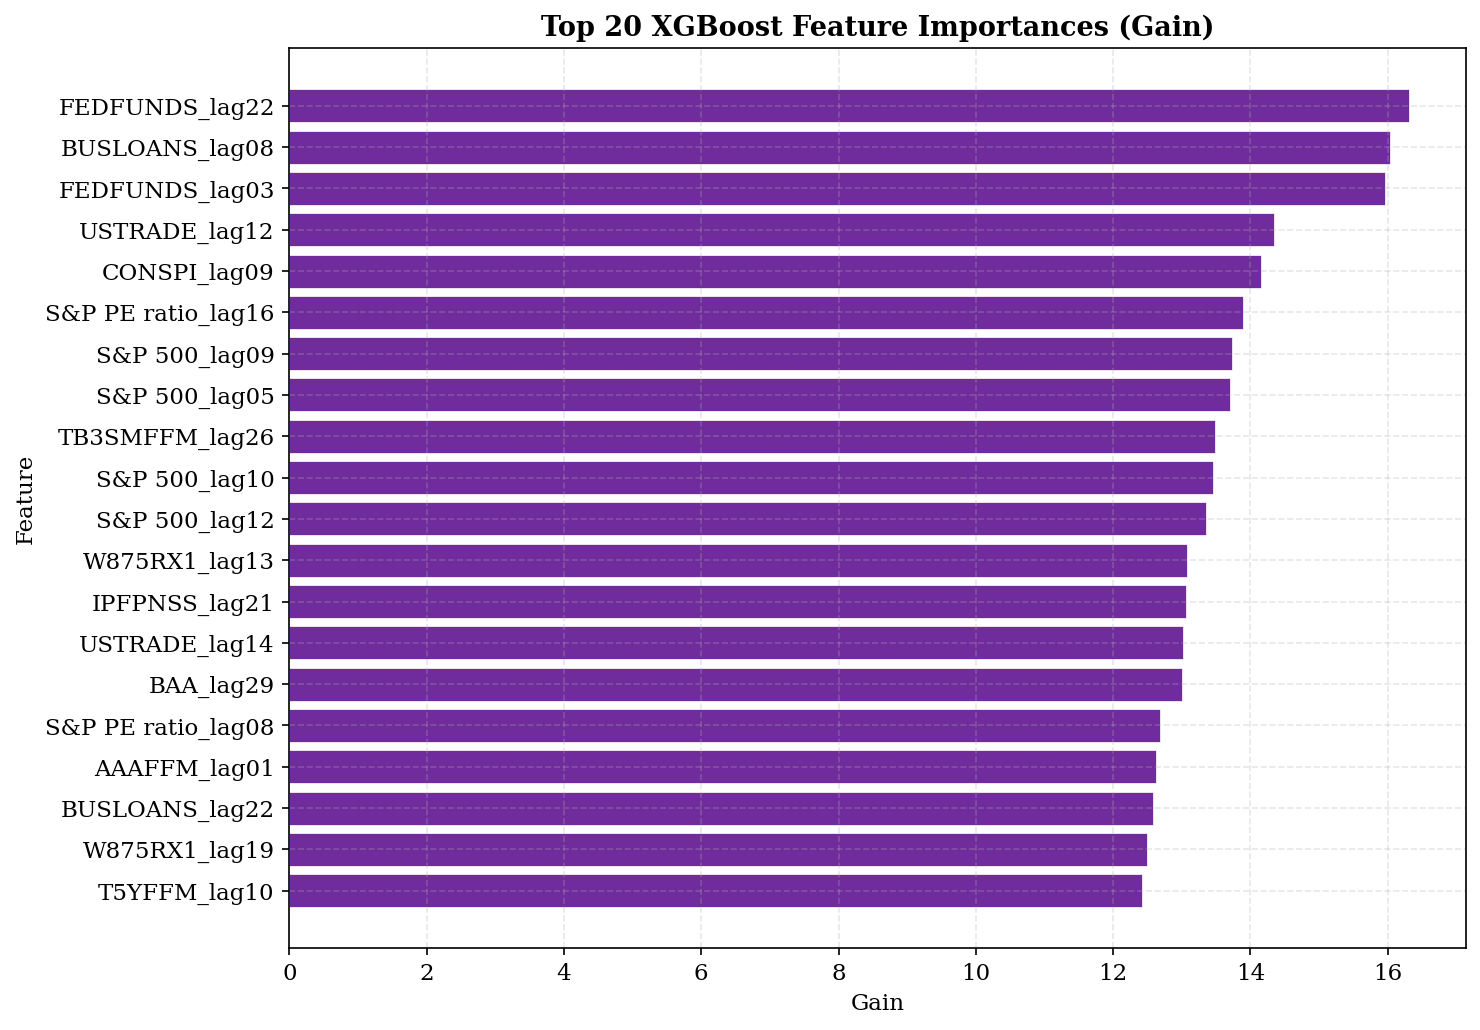


Top 20 features by gain:
           feature  importance
    FEDFUNDS_lag22   16.316080
    BUSLOANS_lag08   16.028547
    FEDFUNDS_lag03   15.954242
     USTRADE_lag12   14.344590
      CONSPI_lag09   14.157169
S&P PE ratio_lag16   13.897489
     S&P 500_lag09   13.726377
     S&P 500_lag05   13.700630
    TB3SMFFM_lag26   13.484481
     S&P 500_lag10   13.459514
     S&P 500_lag12   13.354090
     W875RX1_lag13   13.078643
     IPFPNSS_lag21   13.065441
     USTRADE_lag14   13.009759
         BAA_lag29   13.009132
S&P PE ratio_lag08   12.677623
      AAAFFM_lag01   12.629169
    BUSLOANS_lag22   12.584587
     W875RX1_lag19   12.493279
      T5YFFM_lag10   12.420007


In [17]:
# ============================================================
# Top 20 Feature Importances by Gain
# ============================================================
fi = model.feature_importance(top_n=20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(fi["feature"][::-1], fi["importance"][::-1],
        color=C_PALETTE['model'], edgecolor="white", linewidth=0.4, alpha=0.85)
ax.set_title("Top 20 XGBoost Feature Importances (Gain)",
             fontweight="bold")
ax.set_xlabel("Gain")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

print("\nTop 20 features by gain:")
print(fi.to_string(index=False))

## 17. ROC Curve — Train / Validation / Test

The ROC curve plots the True Positive Rate (recall for Up) against the False Positive Rate at every decision threshold. The diagonal represents a random classifier. AUC closer to 1.0 indicates better discrimination.

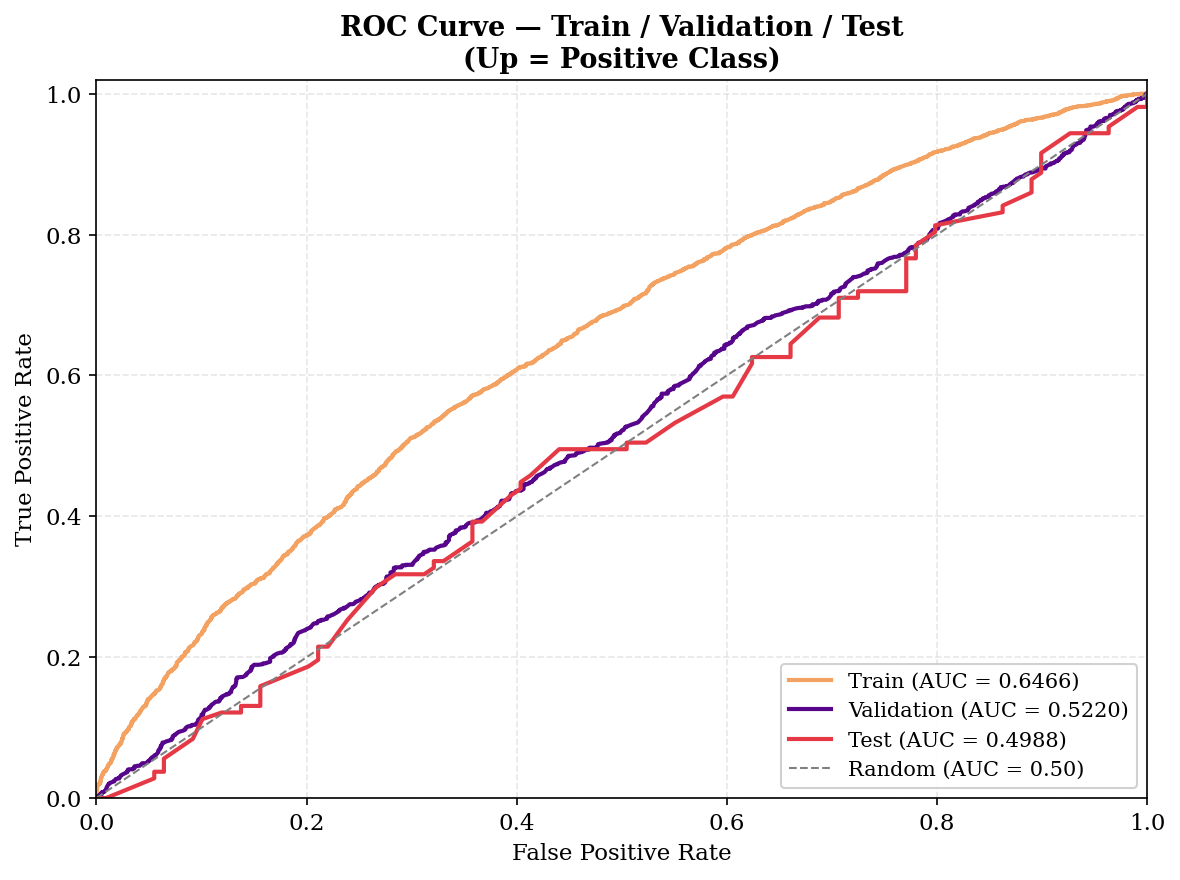

Split             AUC    Accuracy
───────────────────────────────────
Train          0.6466      0.5997
Validation     0.5220      0.5336
Test           0.4988      0.4907


In [18]:
# ============================================================
# ROC Curves — Train, Validation, and Test
# ============================================================
from sklearn.metrics import roc_curve

prob_train = model.predict_proba(X_train)

splits = [
    ("Train",      y_train.values, prob_train, "#f4a261"),
    ("Validation", y_val.values,   prob_val,   C_PALETTE['model']),
    ("Test",       y_test.values,  prob_test,  C_PALETTE['accent']),
]

fig, ax = plt.subplots(figsize=(8, 6))

for label, y_true, y_prob, color in splits:
    fpr, tpr, _ = roc_curve(y_true, y_prob, pos_label=1)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{label} (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], color="gray", lw=1, ls="--", label="Random (AUC = 0.50)")
ax.set_title("ROC Curve — Train / Validation / Test\n(Up = Positive Class)",
             fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.legend(loc="lower right", framealpha=0.9)
plt.tight_layout()
plt.show()

# AUC summary table
print(f"{'Split':<12} {'AUC':>8}  {'Accuracy':>10}")
print("─" * 35)
for label, y_true, y_prob, _ in splits:
    X_split = X_train if label == "Train" else X_val if label == "Validation" else X_test
    y_pred = model.predict(X_split)
    print(f"{label:<12} {roc_auc_score(y_true, y_prob):>8.4f}  "
          f"{accuracy_score(y_true, y_pred):>10.4f}")

## 18. Training Convergence (Error vs. Boosting Rounds)

The plot below shows the classification error (`1 − accuracy`) on the training set and the held-out validation set over all boosting rounds for the final model. Convergence is confirmed when the validation curve flattens and early stopping fires (vertical dashed line). A gap between training and validation error is expected and reflects the difficulty of predicting a near-random daily signal out-of-sample.

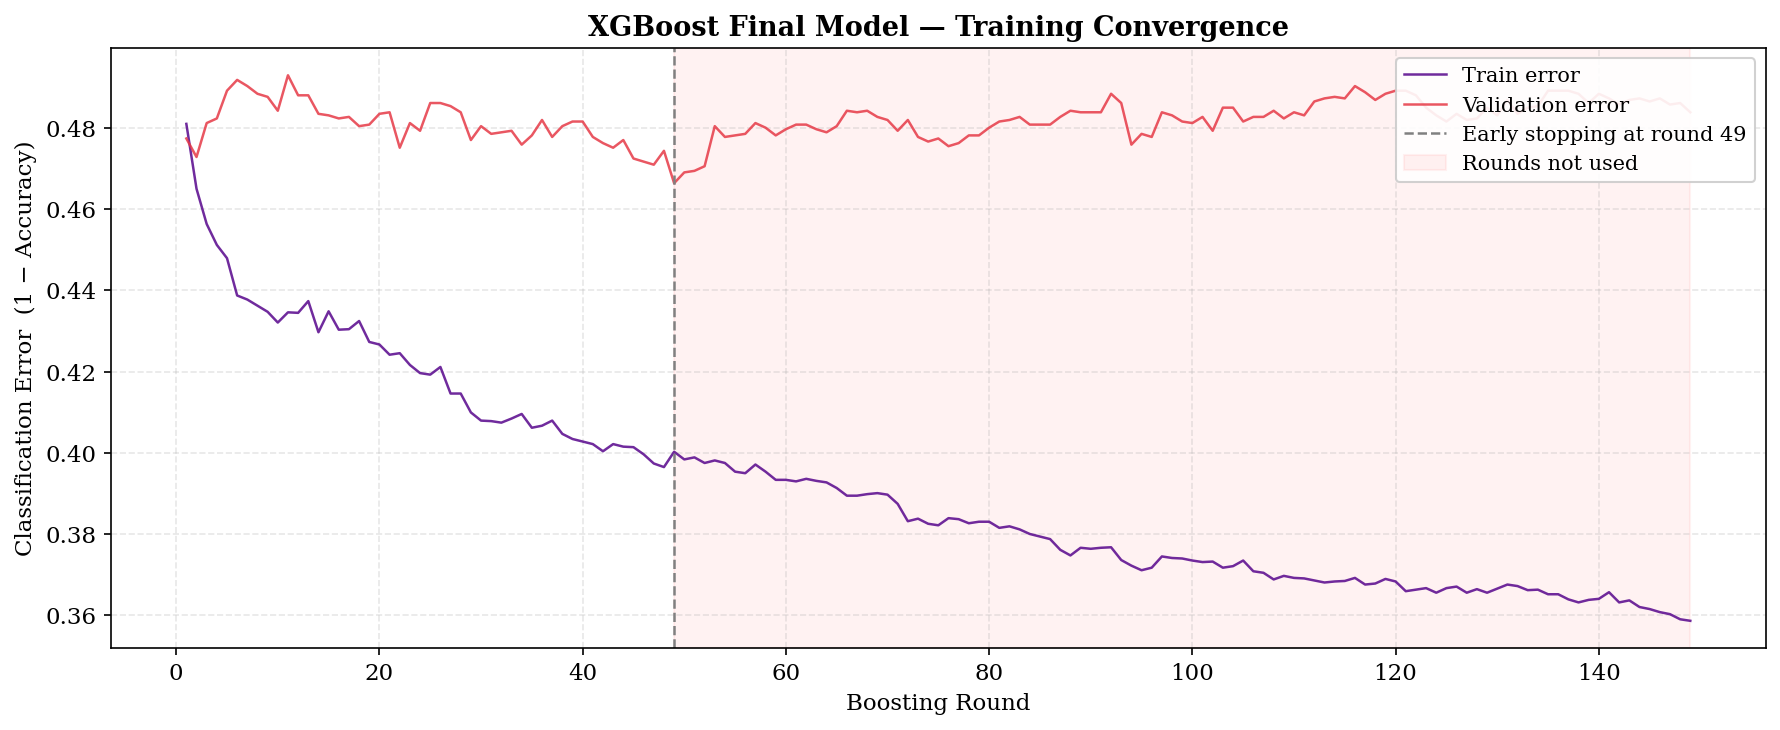

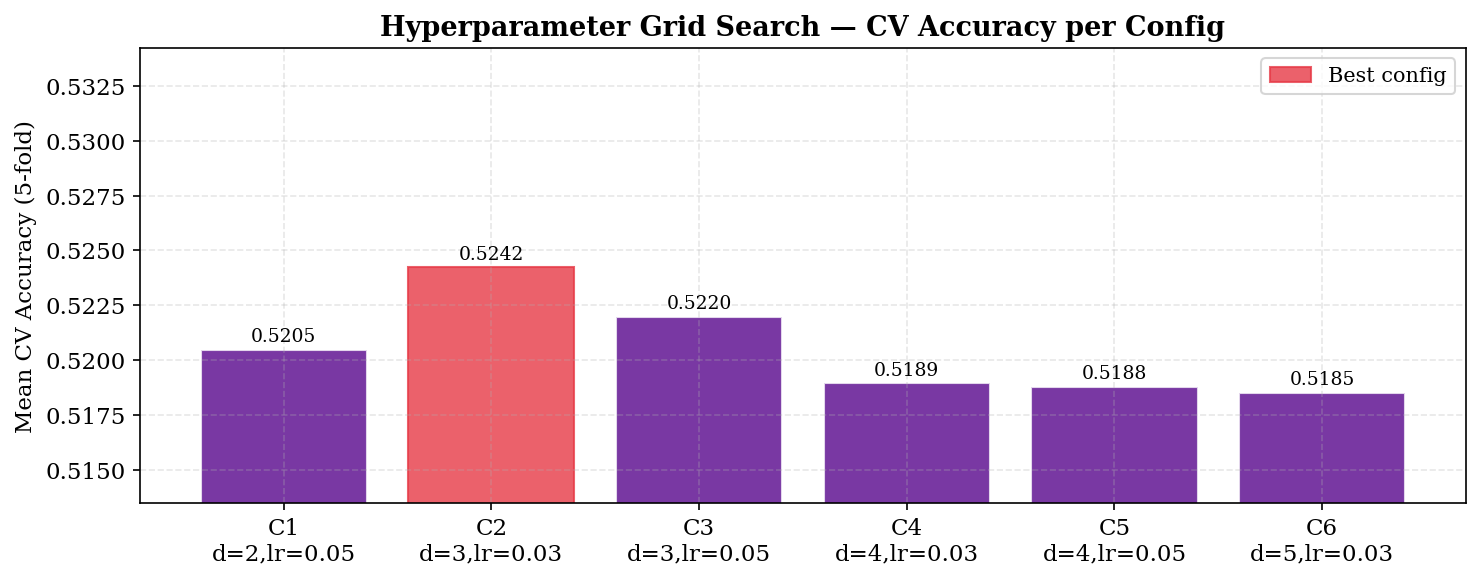

Final model used 49 boosting rounds (early stopping from 1000 max).


In [19]:
# ============================================================
# Training Convergence — Error vs. Boosting Rounds
# ============================================================
er = model.eval_results_
# eval_set order: [0] = training, [1] = validation
train_err = er["validation_0"]["error"]
val_err   = er["validation_1"]["error"]
rounds    = np.arange(1, len(train_err) + 1)

# Best round = where validation error was lowest (early stopping saved this)
best_round = int(model.model.best_iteration) + 1

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(rounds, train_err, color=C_PALETTE['model'], lw=1.2, alpha=0.85, label="Train error")
ax.plot(rounds, val_err,   color=C_PALETTE['accent'],  lw=1.2, alpha=0.85, label="Validation error")

ax.axvline(best_round, color="gray", lw=1.2, ls="--",
           label=f"Early stopping at round {best_round}")

# Shade the region after early stopping
ax.axvspan(best_round, rounds[-1], alpha=0.05, color="red", label="Rounds not used")

ax.set_xlabel("Boosting Round")
ax.set_ylabel("Classification Error  (1 − Accuracy)")
ax.set_title("XGBoost Final Model — Training Convergence", fontweight="bold")
ax.legend(loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.show()

# Also show the CV accuracy across configs as a bar chart
cv_df = pd.DataFrame(model.cv_results_)
config_labels = [f"C{i+1}\nd={p['max_depth']},lr={p['learning_rate']}"
                 for i, p in enumerate([r["params"] for r in model.cv_results_])]

fig2, ax2 = plt.subplots(figsize=(10, 4))
bars = ax2.bar(config_labels, cv_df["accuracy"], color=C_PALETTE['model'],
               alpha=0.8, edgecolor="white")
best_idx = cv_df["accuracy"].idxmax()
bars[best_idx].set_color(C_PALETTE['accent'])
bars[best_idx].set_label("Best config")

for bar in bars:
    ax2.annotate(f"{bar.get_height():.4f}",
                 xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                 xytext=(0, 4), textcoords="offset points",
                 ha="center", fontsize=9)

ax2.set_ylabel("Mean CV Accuracy (5-fold)")
ax2.set_title("Hyperparameter Grid Search — CV Accuracy per Config", fontweight="bold")
ax2.set_ylim(cv_df["accuracy"].min() - 0.005, cv_df["accuracy"].max() + 0.01)
ax2.legend()
plt.tight_layout()
plt.show()

print(f"Final model used {best_round} boosting rounds (early stopping from {model.num_boost_round} max).")

## 18. Save Model

In [20]:
# ============================================================
# Save trained model to disk
# ============================================================
model.save("xgboost_wti_direction.pkl")
print("Model saved to xgboost_wti_direction.pkl")

Model saved to xgboost_wti_direction.pkl
